In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from wordcloud import WordCloud, STOPWORDS
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')

data_dict = {
    'review': [
        'The food was incredibly fresh and the chef was very talented.',
        'Worst meal ever. The pasta was cold and the portion was tiny.',
        'Good location near the city center, but drinks are overpriced.',
        'Absolutely loved my visit! Perfect from start to finish.',
        'Never ordering here again. The delivery was 2 hours late.',
        'Decent place, nothing extraordinary but fair pricing.',
        'Amazing dessert menu, highly recommend the chocolate cake!',
        'The music was too loud and the waiter was dismissive.',
        'Beautiful interior design and very attentive waitstaff. Coming back!',
        'Extremely disappointed with the portion sizes for the price.',
        'Fresh ingredients and creative menu. A hidden gem!',
        'Rude manager and incorrect order. Completely ruined our evening.',
        'Fast service, tasty food, great atmosphere overall.',
        'Cold soup and stale bread. Not acceptable at these prices.',
        'Cozy and romantic setting. Perfect for a date night.',
        'Overcooked steak and mediocre sides. Expected much better.',
        "Staff seemed completely disinterested and forgot half our order.",
        "Warm bread arrived at the table immediately. Small touch, big impact.",
        "The birthday cake surprise was thoughtful and the staff sang along.",
        "Nobody greeted us at the door and we stood waiting for ten minutes.",
        "The dessert was clearly defrosted and tasted of absolutely nothing.",
        "Lovely terrace with a great view. Food matched the scenery.",
        "The burger was raw in the middle. Sent it back and it came back cold.",
        "Extremely disappointing. The menu looked great but the food did not.",
        "Children were made to feel very welcome. Family friendly at its best.",
        "Fantastic brunch options and the fresh juice was outstanding.",
        "Fast service, tasty food, great atmosphere overall.",
        "Cold soup and stale bread. Not acceptable at these prices.",
        "Cozy and romantic setting. Perfect for a date night.",
        "Found a hair in my food and the staff were completely unbothered.",
        "Amazing dessert menu, highly recommend the chocolate cake!",
        "Never ordering here again. The delivery was 2 hours late.",
        "The steak was cooked to perfection and the wine list was excellent.",
        "The restaurant was dirty and the toilets were in a terrible state.",
        "Beautiful interior design and very attentive waitstaff. Coming back!",
        "Overcooked steak and mediocre sides. Expected much better.",
        "Fresh ingredients and creative menu. A hidden gem!",
        "The waiter ignored us for 20 minutes before taking our order.",
        "Best pasta I have ever had. Will definitely return next week.",
        "Disgusting food and terrible service. Waste of money.",
        "The food was incredibly fresh and the chef was very talented.",
        "We waited an hour for food that arrived lukewarm and tasteless.",
        "Absolutely loved my visit! Perfect from start to finish.",
        "Worst meal ever. The pasta was cold and the portion was tiny.",
        "Incredibly friendly staff and the portions were generous.",
        "Rude manager and incorrect order. Completely ruined our evening."
    ],
    'label': [1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,0, 1, 1, 1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0]
}
df = pd.DataFrame(data_dict)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


## 1. Data Exploration


In [ ]:

print(df.head())

print("\nLabel Distribution")
dist = df['label'].value_counts()
print(f"Positive (1): {dist[1]} ({dist[1]/len(df)*100:.1f}%)")
print(f"Negative (0): {dist[0]} ({dist[0]/len(df)*100:.1f}%)")


df['char_length'] = df['review'].apply(len)
print(f"\nShortest review: {df['char_length'].min()} chars")
print(f"Longest review:  {df['char_length'].max()} chars")
print(f"Average length:  {df['char_length'].mean():.1f} chars")
print(f"\nShortest review text: '{df.loc[df['char_length'].idxmin(), 'review']}'")
print(f"Longest review text: '{df.loc[df['char_length'].idxmax(), 'review']}'")

                                              review  label
0  The food was incredibly fresh and the chef was...      1
1  Worst meal ever. The pasta was cold and the po...      0
2  Good location near the city center, but drinks...      1
3  Absolutely loved my visit! Perfect from start ...      1
4  Never ordering here again. The delivery was 2 ...      0

Label Distribution
Positive (1): 24 (52.2%)
Negative (0): 22 (47.8%)

Shortest review: 50 chars
Longest review:  69 chars
Average length:  60.2 chars

Shortest review text: 'Fresh ingredients and creative menu. A hidden gem!'
Longest review text: 'Warm bread arrived at the table immediately. Small touch, big impact.'


**Business Interpretation:** Dataset contains 46 reviews in total. More than half of the reviews are positive (52.2%) but this is still small percentage for real business, customers would not trust this company. But in our case we use this approx balanced data for better models train. Average lenth of review is 60.2 charecters which is long enough to understand customeers sincere emotions and to model to understand more comprehensive and detailed reviews.

## 2. Text Cleaning & Visualization

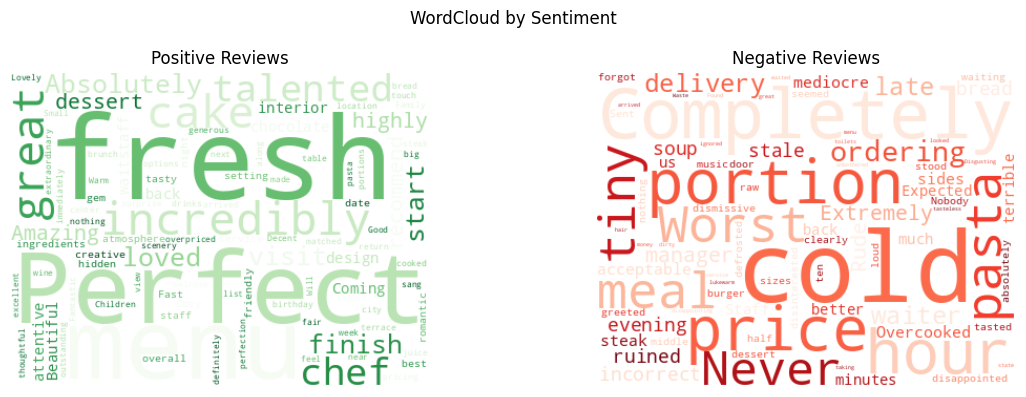

In [ ]:

all_text = ' '.join(df['review'].tolist())
custom_stopwords = STOPWORDS.union({'restaurant', 'food', 'place', 'order', 'came', 'got', 'one'})

wordcloud_all = WordCloud(
    width=800, height=400,
    stopwords=custom_stopwords,
    background_color='white',
    colormap='viridis').generate(all_text)

pos_text = ' '.join(df[df['label'] == 1]['review'].tolist())
neg_text = ' '.join(df[df['label'] == 0]['review'].tolist())

wc_pos = WordCloud(width=400, height=300, stopwords=custom_stopwords, background_color='white', colormap='Greens').generate(pos_text)
wc_neg = WordCloud(width=400, height=300, stopwords=custom_stopwords, background_color='white', colormap='Reds').generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews')
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews')
plt.suptitle('WordCloud by Sentiment')
plt.tight_layout()
plt.show()

**Business Interpretation:** with word clouds we can understand and vizualize the most common words in reviews. Positive reviews containes  words fresh , chef, drinks, city center, menu, cake. SO it represents strong sides of restaurent. Negative reviews containes cold, pasta, price, portion, tiny, waiter, late and loud . These are sides that lacks in our restaurant. businesses can use it to strengthen this parts of business.

## 3. Advanced Filtering with Regex

In [ ]:

import nltk
nltk.download('punkt_tab')
def clean_tokens(text):
    tokens = word_tokenize(text.lower())
    return [t for t in tokens if t.isalpha() and t not in custom_stopwords]

df['clean_tokens'] = df['review'].apply(clean_tokens)
print("Cleaned tokens (first 3)")
for i in range(3):
    print(f"  Original: {df['review'].iloc[i]}")
    print(f"  Cleaned:  {df['clean_tokens'].iloc[i]}\n")

print("Reviews mentioning 'service' (case-insensitive")
pattern = re.compile(r'\bservice\b', re.IGNORECASE)
service_reviews = df[df['review'].apply(lambda x: bool(pattern.search(x)))]
print(f"Found {len(service_reviews)} reviews:")
for _, row in service_reviews.iterrows():
    label = "POS" if row['label'] == 1 else "NEG"
    print(f"  [{label}] {row['review']}")

keywords = ['service', 'staff', 'delivery', 'price', 'quality']
print("\nKeyword frequency in reviews")
for kw in keywords:
    pat = re.compile(rf'\b{kw}\b', re.IGNORECASE)
    count = df['review'].apply(lambda x: bool(pat.search(x))).sum()
    print(f"  '{kw}': {count} reviews")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Cleaned tokens (first 3)
  Original: The food was incredibly fresh and the chef was very talented.
  Cleaned:  ['incredibly', 'fresh', 'chef', 'talented']

  Original: Worst meal ever. The pasta was cold and the portion was tiny.
  Cleaned:  ['worst', 'meal', 'pasta', 'cold', 'portion', 'tiny']

  Original: Good location near the city center, but drinks are overpriced.
  Cleaned:  ['good', 'location', 'near', 'city', 'center', 'drinks', 'overpriced']

Reviews mentioning 'service' (case-insensitive
Found 3 reviews:
  [POS] Fast service, tasty food, great atmosphere overall.
  [POS] Fast service, tasty food, great atmosphere overall.
  [NEG] Disgusting food and terrible service. Waste of money.

Keyword frequency in reviews
  'service': 3 reviews
  'staff': 4 reviews
  'delivery': 2 reviews
  'price': 1 reviews
  'quality': 0 reviews


**Business Interpretation:** use of regex to  find reviews that have specific words as "service" helpful in identifying the perfomance of services, in businesses we can use it to analyzing the quality of specific parts. "Service" used in 2 positive (and 1 negative) reviews and it says that our service is fast so it does not need to be changed in case of speed. But neggative says that it is bad so we need to check
 Cleaning tokens by deleting non letter simbols and words that does not make sense is usefull to make analysis of reviews and use it in datasets. For example in this case to us its better to use cleaned reviews of past and present to compare

##  4. Feature Extraction

In [ ]:

df['text_for_model'] = df['clean_tokens'].apply(lambda x: ' '.join(x))

vectorizer = CountVectorizer(ngram_range=( 1,2))
X = vectorizer.fit_transform(df['text_for_model'])

print(f"Matrix shape: {X.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")


vocab = vectorizer.get_feature_names_out()
unigrams = [v for v in vocab if ' ' not in v][:10]
bigrams = [v for v in vocab if ' ' in v][:10]
print(f"\nSample unigrams: {unigrams}")
print(f"Sample bigrams:  {bigrams}")


freq = X.sum(axis=0).A1
freq_df = pd.DataFrame({'feature': vocab, 'count': freq}).sort_values('count', ascending=False)
print("\nTop-10 features:")
print(freq_df.head(10).to_string(index=False))

print(X)

Matrix shape: (46, 336)
Vocabulary size: 336

Sample unigrams: ['absolutely', 'acceptable', 'along', 'amazing', 'arrived', 'atmosphere', 'attentive', 'back', 'beautiful', 'best']
Sample bigrams:  ['absolutely loved', 'absolutely nothing', 'acceptable prices', 'amazing dessert', 'arrived lukewarm', 'arrived table', 'atmosphere overall', 'attentive waitstaff', 'back back', 'back cold']

Top-10 features:
   feature  count
     fresh      5
      cold      5
      menu      5
     staff      4
      back      4
     great      4
completely      4
   perfect      4
     bread      3
     pasta      3
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 501 stored elements and shape (46, 336)>
  Coords	Values
  (0, 151)	1
  (0, 117)	1
  (0, 38)	1
  (0, 286)	1
  (0, 152)	1
  (0, 118)	1
  (0, 39)	1
  (1, 334)	1
  (1, 181)	1
  (1, 218)	1
  (1, 48)	1
  (1, 226)	1
  (1, 301)	1
  (1, 335)	1
  (1, 182)	1
  (1, 219)	1
  (1, 49)	1
  (1, 228)	1
  (2, 126)	1
  (2, 163)	1
  (2, 198)	1
  (2, 44)	1

**Business Interpretation:** we need to identify unigrams and bigrams, because single "absolutely" may be both negative and positive, so to understand the true meaning we need to see the phrase, so it became "absolutely loved" whick has positive comtext, but also "absolutely nothing" so wwe should check it. Top features shows how many uni,bi grams were found


## 5. Sentiment Prediction

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix

y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))




new_reviews = [  "service is disapointing and food is overcooked!", "hate this place, food is burned and stuff is rude", "Overpriced for what you get. Tiny portions and bland flavours.",
        "Lovely ambiance and the seafood platter was absolutely divine.",
]
new_processed = [' '.join([t for t in word_tokenize(r.lower()) if t.isalpha()]) for r in new_reviews]
new_X = vectorizer.transform(new_processed)
new_preds = clf.predict(new_X)
new_probs = clf.predict_proba(new_X)

print("\nPredictions on new reviews:")
for text, pred, prob in zip(new_reviews, new_preds, new_probs):
    label = "POSITIVE" if pred == 1 else "NEGATIVE"
    print(f"  [{label} {max(prob):.2f}] {text}")

Train size: 36, Test size: 10

Accuracy: 0.70

Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.75      0.67         4
    Positive       0.80      0.67      0.73         6

    accuracy                           0.70        10
   macro avg       0.70      0.71      0.70        10
weighted avg       0.72      0.70      0.70        10


Predictions on new reviews:
  [NEGATIVE 0.56] service is disapointing and food is overcooked!
  [NEGATIVE 0.57] hate this place, food is burned and stuff is rude
  [NEGATIVE 0.53] Overpriced for what you get. Tiny portions and bland flavours.
  [POSITIVE 0.51] Lovely ambiance and the seafood platter was absolutely divine.


**Business Interpretation:** Accuracy of model 0.7. This means the model correctly classifies 70% of
  reviews as positive or negative. For a baseline model using simple
  word counts and logistic regression.
  Precision: o,7. Of all reviews the model labelled "positive", 0.7 part were actually positive. Recall: 0.7 . Of all truly positive reviews, 70% fraction did the model find.